[2025-12-09] - [Emil] - [Skeleton API Deployment]

**What I worked on:**
- I implemented `/deployment/app.py` utilizing the FastAPI framework to build a service that accepts feature vectors as input and returns a prediction of DoS or benign traffic.
- The best performing model was trained and saved to disk as a `.pkl` file - this model was `random_forest.pkl`.  

Below is the code stored in the `deployment/app.py` file:

```
from fastapi import FastAPI, HTTPException
import joblib
from pathlib import Path
import sys

# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from deployment.schema_loader import load_schema
from deployment.preprocessing import Preprocessor

# First we create a new FastAPI object
app = FastAPI(
    title = "DoS Classifier API",
    version = "0.1.0",
    description = "API for predicting DoS attacks vs. benign traffic"
)

# Load the schema
SCHEMA_PATH = Path(project_root / "data/final_features.json")
schema = load_schema(SCHEMA_PATH)

# Then we create the preprocessor object.
preprocessor = Preprocessor(schema_path = SCHEMA_PATH)

# Load the trained model
MODEL_PATH = Path("models/saved_model/random_forest.pkl")

# This logic is required because as of the writing of this code, no model has been trained. 
if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
else:
    model = None

# Implementation of health check endpoint
@app.get("/health")
def health_check():
    return {"status": "ok"}

# Implementation of version endpoint
@app.get("/version")
def version():
    return {"api_version": "0.1.0"}

# Implementation of prediction endpoint (inference not yet implemented)
@app.post("/predict")
def predict(input_data: dict):
    # Running preprocessing with sanity checking.
    try:
        X = preprocessor.preprocess_input(input_data)
    except Exception as e:
        raise HTTPException(
            status_code = 400, 
            detail = f"Failed to preprocess input data: {e}"
        )
    try:
        y_pred = model.predict(X)
    except Exception as e:
        raise HTTPException(
            status_code = 500, 
            detail = f"Failed to make predictions: {e}"
        )
    return {"prediction": int(y_pred[0])}
```

**Interpretation / Findings:**  
In this script, the deployment layer is implemented of our intrusion-detection classifier. It loads the project's `final_features.json` schema and the best-performing trained model to create a reproducible inference pipeline. Incoming rquests to the `/predict` endpoint are validated to ensure correct feature names, types, and ordering. The API then applies the same preprocessing steps used in training, passes the transformed input to the loaded classifier, and returns the predicted class label. I also implemented two endpoints, `/health` and `/version`, which serve as health checks and version endpoints, respectively - entirely diagnostic. 

**Notes for Team:**  
This is testable code - we can begin to write unit/Postman tests.

### Done with Task

[2025-12-09] - [Emil] - [Preprocessing for API]

**What I worked on:**
- I implemented the `preprocess_input` method in the `Preprocessor` class to transform incoming feature vectors into a format that can be consumed by the trained model. This file is found in `deployment/preprocessing.py`.
- I implemented the `load_schema` method in the `schema_loader.py` file to load the project's `final_features.json` schema.

Below is the code stored in the `deployment/preprocessing.py` file:

```
import json
import numpy as np
from pathlib import Path

class Preprocessor:
    def __init__(self, schema_path: str):
        """
        Instantiator method for the preprocessor class. 
        
        :param self: This object.
        :param schema_path: The path to the final_features.json file.
        """
        self.schema_path = Path(schema_path)

        # First we need to load the schema
        with open(self.schema_path, "r") as f:
            schema = json.load(f)
        
        # Then we need to extract the scaler parameters from final_features.json
        scaler_params = schema["scaler_params"]

        self.feature_names = scaler_params["feature_names"]
        self.feature_means = np.array(scaler_params["feature_means"], dtype = float)
        self.feature_stds = np.array(scaler_params["feature_stds"], dtype = float)

        # Sanity check to ensure the feature names, means, and stds are the same length
        if len(self.feature_names) != len(self.feature_means) or len(self.feature_names) != len(self.feature_stds):
            raise ValueError("Feature names, means, and stds are not the same length")

        # Convert the numeric types to a dictionary for faster lookup. 
        self.numeric_types = {
            k: v["dtype"]
            for k, v in schema.items()
            if isinstance(v, dict) and v.get("feature_type") == "numeric" and not k.startswith("_") and k != "scaler_params"
        }
        
        self.n_features = len(self.feature_names)

    def validate_input(self, sample: dict):
        # Check for missing fields. 
        for f in self.feature_names:
            if not f in sample:
                raise ValueError(f"Missing feature {f}")
        
        # Check for unexpected fields.
        for k in sample.keys():
            if k not in self.feature_names:
                raise ValueError(f"Unexpected feature {k}")
        
        # Validate the numeric types.
        for key, value in sample.items():

            # Raise exception if the value is null.
            if value is None:
                raise ValueError(f"Field '{key}' cannot be null.")
            
            # Try to typecast the value to numeric, otherwise raise exception.
            if not isinstance(value, (int, float)):
                try:
                    sample[key] = float(value)
                except:
                    raise ValueError(f"Field '{key}' must be numeric, but value is '{value}' with type {type(value)}.")
                
        return sample
    
    def safe_scaling(self, X):
        """
        Safely scales the dataset by avoiding divide by zero errors.
        
        :param self: This object.
        :param X: The dataset to be scaled (numpy array). 
        """
        # If the std is too small, replace it with 1.0
        safe_stds = np.where(self.feature_stds < 1e-12, 1.0, self.feature_stds)

        # Apply the scaling.
        return (X - self.feature_means) / safe_stds

    def preprocess_input(self, sample: dict):
        """
        Takes a dictionary containing raw feature inputs
        and returns a (1, n_features) scaled numpy array. 

        Missing features are filled with 0.0.
        
        :param self: This object.
        :param sample: The dictionary containing raw feature inputs.
        """
        # First validate the input
        sample = self.validate_input(sample)

        # Then order the features.
        ordered = [sample[f] for f in self.feature_names]

        # Then we convert to a dataframe and scale and reshape the array for prediction.
        X = np.array(ordered, dtype = float).reshape(1, -1)
        
        # Apply scaling.
        X_scaled = self.safe_scaling(X)

        return X_scaled
```

Below is the code stored in the `deployment/schema_loader.py` file:
```
import json
from pathlib import Path

def load_schema(schema_path: Path):
    """
    Loads the project's `final_features.json` schema.

    :param schema_path: Path to the schema file.
    """
    schema_path = Path(schema_path)

    # Check if the schema_path exists.
    if not schema_path.exists():
        raise FileNotFoundError(f"Schema file not found at {schema_path}")

    with open(schema_path, "r") as f:
        schema = json.load(f)

    # Added sanity checking to ensure all keys are present.
    required_sections = ["scaler_params", "_metadata"]
    for section in required_sections:
        if section not in schema:
            raise KeyError(f"Required section '{section}' not found in schema")

    # Validating if length of scaling arrays match length of feature list.
    scaler = schema["scaler_params"]
    if not (len(scaler["feature_names"]) == len(scaler["feature_means"]) == len(scaler["feature_stds"])):
        raise ValueError("Length of scaling arrays does not match length of feature list")

    return schema
```

**Interpretation / Findings:**  
The preprocessor class is responsible for enforcing strict input validation and for preparing incoming JSON data for inference. When a request arrives at the `/predict` endpoint, the preprocessor loads the project's feature schema stored in `final_features.json`. We do this to make sure that input contains all expected features, includes no unexpected features, and every value is numeric and non-null (performing coercion where possible). After validation, features are reordered to exactly match layout used during model training. The preprocessor then applies the same scaling applied during training. The entire preprocessing pipeline then returns a NumPy array ready to be passed into the trained model. The schema loader function is responsible for loading the project's `final_features.json` schema. It includes some sanity checking to ensure all keys are present and that the length of the scaling arrays match the length of the feature list.

**Notes for Team:**  
Also testable code!!!

[2025-12-09] - [Emil] - [Deployment Tests]

**What I worked on:**  
- I implemented in the code below some edge cases to validate that the preprocessing pipeline works as expected.

In [4]:
import sys
from pathlib import Path
# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from deployment.preprocessing import Preprocessor
from deployment.schema_loader import load_schema
import pandas as pd


# Load the schema
schema_path = project_root / "data" / "final_features.json"
schema = load_schema(schema_path)

# Create the preprocessor object
preprocessor = Preprocessor(schema_path)

# Load an example feature vector from the cleaned dataset
df = pd.read_csv(project_root / "data" / "cleaned" / "wednesday_cleaned.csv")
# Get a sample feature vector, dropping the labels.
sample = df.iloc[0].drop(labels = ["Label", "Attack"]).to_dict()

# Testing preprocessing works as expected.
    # This should return 2D array with correct scaling with NaN's removed.
X = preprocessor.preprocess_input(sample)
print(X[:5])
print(X.shape)

# Testing Edge Case 1: Missing Feature
    # We copy the sample and remove the "Flow_Duration" feature
    # This should fail
sample_missing = sample.copy()
sample_missing.pop("Flow_Duration")
try:
    preprocessor.preprocess_input(sample_missing)
except Exception as e:
    print(f"Edge Case 1: Missing Feature passed: {e}")
else:
    print("Edge Case 1: Missing Feature failed.")

# Testing Edge Case 2: Extra Feature
    # We copy the sample and add an extra feature
    # This should fail
sample_extra = sample.copy()
sample_extra["FakeFeature"] = 999
try:
    preprocessor.preprocess_input(sample_extra)
except Exception as e:
    print(f"Edge Case 2: Extra Feature passed: {e}")
else:
    print("Edge Case 2: Extra Feature failed.")

# Testing Edge Case 3: Wrong Data Type
    # We copy the sample and change the data type of a feature
    # This should fail
sample_wrong_type = sample.copy()
sample_wrong_type["Flow_Duration"] = "not_a_number"
try:
    preprocessor.preprocess_input(sample_wrong_type)
except Exception as e:
    print(f"Edge Case 3: Wrong Data Type passed: {e}")
else:
    print("Edge Case 3: Wrong Data Type failed.")

# Testing Edge Case 4: Null Values
    # We copy the sample and change the feature to null
    # This should fail
sample_null = sample.copy()
sample_null["Flow_Duration"] = None
try:
    preprocessor.preprocess_input(sample_null)
except Exception as e:
    print(f"Edge Case 4: Null Values passed: {e}")
else:
    print("Edge Case 4: Null Values failed.")

[[-5.44523491e-02 -9.75796567e-01 -6.20770529e-02 -3.11910947e-02
  -2.48415997e-01 -3.03189749e-02 -8.21251603e-01 -9.85274740e-02
  -4.24007280e-01 -8.52963483e-01 -1.03045482e+00 -1.68394212e-01
  -1.09424950e+00 -1.00476992e+00 -5.19354910e-02 -2.93954970e-01
  -4.78955371e-01 -7.58748902e-01 -8.94945340e-01 -2.39048250e-01
  -9.30067756e-01 -5.88177393e-01 -7.50651742e-01 -8.89878521e-01
  -2.72550196e-01 -4.70992203e-01 -3.89044269e-01 -4.07976751e-01
  -4.27896037e-01 -7.24757718e-02 -1.40827541e-01 -9.59468238e-02
  -4.81206968e-02 -2.90839820e-01 -7.09344991e-02 -1.35858737e-01
  -1.04834806e+00 -1.15693452e+00 -1.09080540e+00 -8.36777120e-01
  -3.82025401e-01 -1.40827541e-01 -6.40197519e-03 -7.53004386e-01
   1.05304432e+00  6.64090834e+00 -6.40197519e-03  1.36670283e+00
  -1.15369665e+00 -4.24007280e-01 -1.09424950e+00 -6.20770529e-02
  -2.48415997e-01 -3.11910947e-02 -3.03177243e-02 -7.36217347e-01
  -6.96324672e-02 -2.16092942e-02  4.21317660e-01 -2.70395753e-01
  -7.70878

**Interpretation/Findings:**  
Here I correctly imported modules required from the rest of the project. While I won't go back and correct work, figuring out how to correctly import modules using a jupyter notebook was tricky and I saw that other notebooks simply reimplemented code that was put in other python scripts. But in the end, we got the same result - just lost some of the intended modularity. This script evaluates whether the deployed preprocessing pipeline behaves consistently with the training pipeline and enforces the constraints correctly. It loads the project's schema and initializes a `Preprocessor` object, ensuring transformations use the same feature order, data types, and scaling parameters established during training. Using a real row from the cleaned dataset, the script verifies that array is 2D and scaled appropriately. We also put in four edge-case tests to verify detection of missing features, unexpected features, wrong data types, and null values. These tests ensure that the pipeline detects malformed or incomplete inputs. 

[2025-12-09] - [Emil] - [Postman Tests]

**What I worked on:**  
- I generated representative samples for both attack and benign samples from the dataset. These samples allow us to test the `/predict` endpoint with Postman. 
- In the below code, I randomly select a benign and attack sample from the cleaned dataset.

The vectors are saved in `deployment/sample_requests/benign_sample.json` and `deployment/sample_requests/attack_sample.json` respectively. The code to generate those files is below. In that code, we first filter based on the label (either BENIGN or if the string contains DoS), randomly sample (with a set random state for reproducible selection), then remove columns for attack and label, convert the 1-row dataframe to a Series and finally convert to a dictionary.

In [5]:
import sys
from pathlib import Path
import json
# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

# Load an example feature vector from the cleaned dataset
df = pd.read_csv(project_root / "data" / "cleaned" / "wednesday_cleaned.csv")
benign_sample = df[df["Label"] == "BENIGN"].sample(1, random_state=42).drop(columns=["Label", "Attack"]).iloc[0].to_dict()
attack_sample = df[df["Label"].str.contains("DoS")].sample(1, random_state=42).drop(columns=["Label", "Attack"]).iloc[0].to_dict()

# Save to .json files.
with open(project_root / "deployment" / "sample_requests" / "benign_sample.json", "w") as f:
    json.dump(benign_sample, f, indent=2)
with open(project_root / "deployment" / "sample_requests" / "attack_sample.json", "w") as f:
    json.dump(attack_sample, f, indent=2)

Again, the data used to test the API is found in the `deployment/sample_requests` directory.

To test the `/predict` endpoint and other endpoints yourself, do the following:
1. Download and install uvicorn on your machine and `cd` into the `deployment` directory in the terminal of your choice.
2. Run `uvicorn app:app` in the terminal (windows users use python3 -m uvicorn app:app). The URL should be http://127.0.0.1:8000, simply type that into the Postman URL bar and add the endpoint you want to test at the end (see unit tests below for examples). 
3. Download and install Postman on your machine.
4. Open Postman and send a GET request to the `/health` endpoint. This should return:
```
{
    "api_version": "0.1.0"
}
```
5. Send a GET request to the `/version` endpoint. This should return:
```
{
    "status": "ok"
}
```
6. Send a POST request to the `/predict` endpoint with the benign sample vector. This should return:
```
{
    "prediction": 0
}
```
7. Send a POST request to the `/predict` endpoint with the attack sample vector. This should return:
```
{
    "prediction": 1
}
```

Below is an image of the health endpoint:  
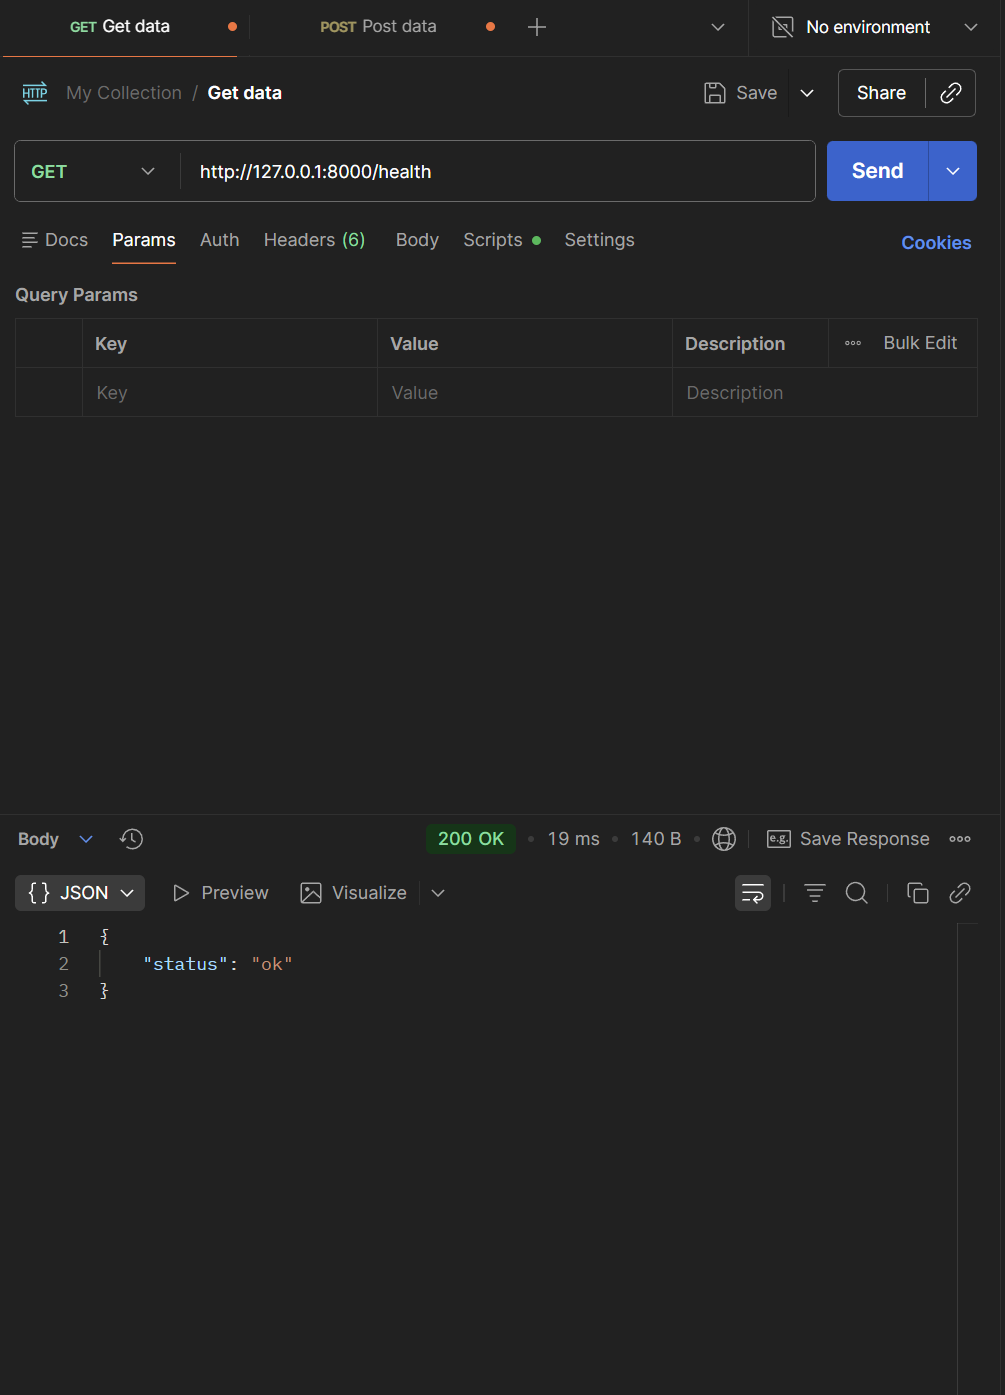  

Below is an image of the version endpoint:  
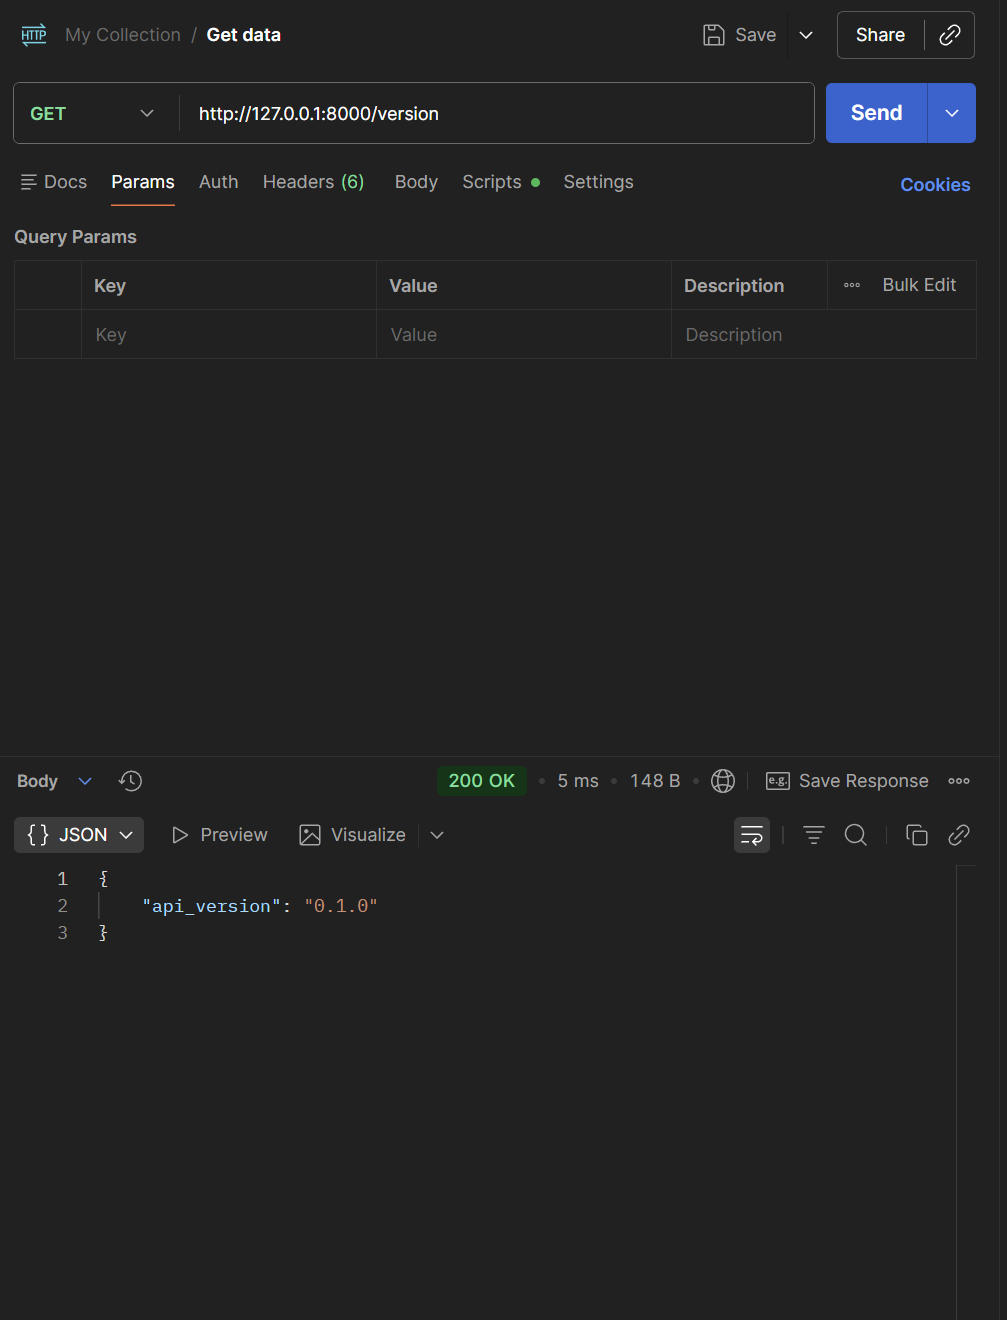  

Below is an image of the prediction endpoint (benign sample):  
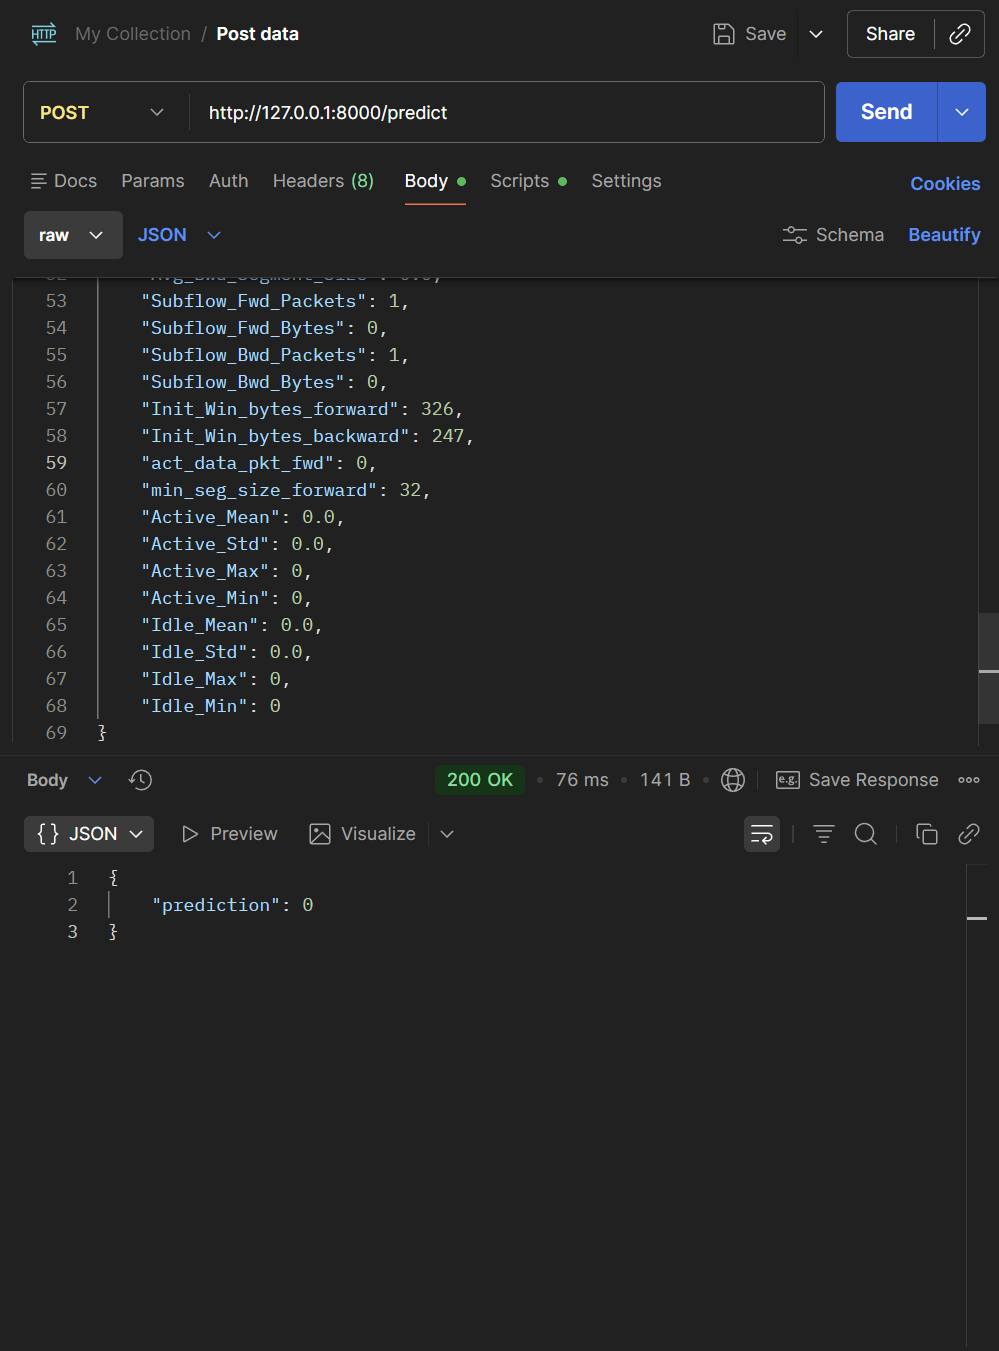  

Below is an image of the prediction endpoint (attack sample):  
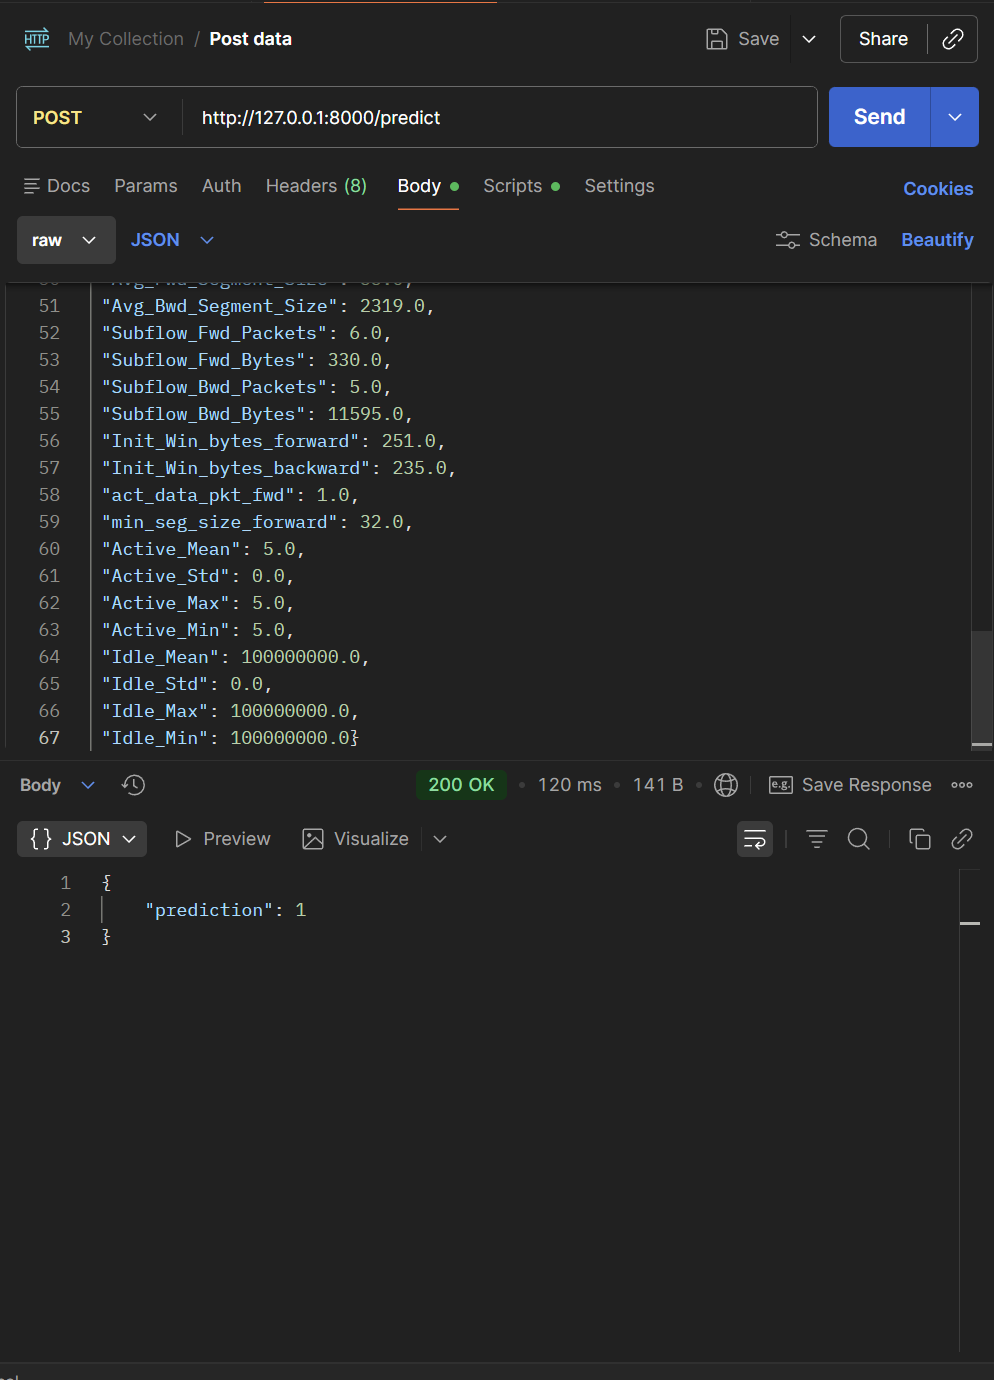  

**Notes for Team:**  
YAY!!! WE DID IT!!!



[12-09-2025] - [Emil] - [Deployment Unit Testing]

**What I worked on:**
- To completely test the API following its deployment, we need to design unit tests. 
- To do so, we will implement a test suite utilizing the samples we generated above. 
- Not going to go into depth about rationale - it is the same as above. 
- It would be of note that if this development were in a production setting, having separate modules for testing and deployment would be preferred. 

In [6]:
import sys
from pathlib import Path
import json
import requests
import pandas as pd

# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from deployment.schema_loader import load_schema
from deployment.preprocessing import Preprocessor

# Load the schema
schema_path = project_root / "data" / "final_features.json"
schema = load_schema(schema_path)

# Create the preprocessor object
preprocessor = Preprocessor(schema_path)

# Setting dir variables, these files were generated earlier
sample_dir = project_root / "deployment" / "sample_requests"
benign_sample_path = sample_dir / "benign_sample.json"
attack_sample_path = sample_dir / "attack_sample.json"

# Manual preprocessor tests
X = preprocessor.preprocess_input(json.load(open(benign_sample_path)))
print("Shape: ", X.shape)
print(X[:2])

# API Tests (To Use, please ensure uvicorn is running)
API_URL_PREDICT = "http://127.0.0.1:8000/predict"
API_URL_HEALTH = "http://127.0.0.1:8000/health"
API_URL_VERSION = "http://127.0.0.1:8000/version"

def test_api(sample):
    response = requests.post(API_URL_PREDICT, json=sample)
    print(response.json())

print("Testing Benign Sample:")
test_api(json.load(open(benign_sample_path)))

print("Testing Attack Sample:")
test_api(json.load(open(attack_sample_path)))

Shape:  (1, 67)
[[-0.12268812 -0.97783797 -0.04946974 -0.02182382 -0.20158934 -0.02924796
  -0.70792984  0.18280939 -0.17773179 -0.85296348 -0.99067171  4.81304428
  -0.95889928 -1.00476992 -0.01461626 -0.23810427 -0.48429969 -0.75874324
  -0.89699739 -0.2445583  -0.93006766 -0.58817719 -0.75065174 -0.88987843
  -0.27254999 -0.47099066 -0.38903884 -0.40797675 -0.42789445 -0.07246097
  -0.14082754 -0.09095873 -0.04438    -0.26274349  0.33456355  1.24761349
  -1.00827487 -0.97762239 -1.03621571 -0.83563846 -0.3820254  -0.14082754
  -0.00640198 -0.75300439 -0.94962765 -0.15058181 -0.00640198  1.36670283
  -0.94863343 -0.17773179 -0.95889928 -0.04946974 -0.20158934 -0.02182382
  -0.02924677 -0.75958023 -0.14317981 -0.00879242 -1.75837367 -0.27039575
  -0.0770879  -0.27149488 -0.25964926 -0.85634609 -0.18780103 -0.87804704
  -0.83181229]]
Testing Benign Sample:
{'prediction': 0}
Testing Attack Sample:
{'prediction': 1}
